In [25]:
import warnings
warnings.filterwarnings('ignore', category=pd.errors.Pandas4Warning)

In [26]:
!pip install scipy



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
# ============================================
# STEP 1: LOAD THE STUDENT PERFORMANCE DATASET
# ============================================

# Import required library
import pandas as pd
import os

print("=" * 60)
print("📊 STUDENT PERFORMANCE DATA ANALYSIS")
print("=" * 60)
print("\n🔄 STEP 1: Loading Dataset...")

# Check current working directory
current_dir = os.getcwd()
print(f"📁 Current directory: {current_dir}")

# Try to load the dataset
try:
    # If your file is in Downloads folder, use this:
    # df = pd.read_csv(r'C:\Users\vishw\Downloads\student-mat.csv')
    
    # OR if you moved it to the current directory, use this:
    df = pd.read_csv('student-mat-final (1).csv')
    
    print("✅ SUCCESS! Dataset loaded successfully!")
    
    # Display basic information
    print("\n" + "=" * 60)
    print("📋 DATASET INFORMATION")
    print("=" * 60)
    print(f"▶ Number of rows: {df.shape[0]}")
    print(f"▶ Number of columns: {df.shape[1]}")
    print(f"▶ Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Show column names
    print("\n📌 Column Names (33 columns):")
    print("-" * 40)
    for i, col in enumerate(df.columns, 1):
        print(f"{i:2d}. {col}")
    
    # Display first few rows
    print("\n🔍 First 5 rows of data:")
    print("-" * 40)
    print(df.head())
    
    # Show data types
    print("\n📊 Data Types of First 5 Columns:")
    print("-" * 40)
    print(df.dtypes.head())
    
    # Quick statistics
    print("\n📈 Quick Statistics of Numeric Columns:")
    print("-" * 40)
    print(df.describe())
    
    print("\n" + "=" * 60)
    print("✅ STEP 1 COMPLETED SUCCESSFULLY!")
    print("=" * 60)
    print("\n💡 Next Steps:")
    print("   1. Create a new cell below (Press 'B' or click + button)")
    print("   2. Start STEP 2: Explore & Clean Data")
    
except FileNotFoundError:
    print("\n❌ ERROR: Could not find the file 'student-mat.csv'")
    print("\n🔍 Please check:")
    print("   1. Is the file in the current directory?")
    print(f"      Current directory: {current_dir}")
    print("\n   2. Try specifying the full path:")
    print('      df = pd.read_csv(r"C:\\Users\\vishw\\Downloads\\student-mat.csv")')
    
    # Show files in current directory
    print("\n📂 Files in current directory:")
    for file in os.listdir(current_dir):
        if file.endswith('.csv'):
            print(f"   📄 {file}")

📊 STUDENT PERFORMANCE DATA ANALYSIS

🔄 STEP 1: Loading Dataset...
📁 Current directory: C:\Users\vishw\Downloads
✅ SUCCESS! Dataset loaded successfully!

📋 DATASET INFORMATION
▶ Number of rows: 395
▶ Number of columns: 33
▶ Memory usage: 0.43 MB

📌 Column Names (33 columns):
----------------------------------------
 1. school
 2. sex
 3. age
 4. address
 5. famsize
 6. Pstatus
 7. Medu
 8. Fedu
 9. Mjob
10. Fjob
11. reason
12. guardian
13. traveltime
14. studytime
15. failures
16. schoolsup
17. famsup
18. paid
19. activities
20. nursery
21. higher
22. internet
23. romantic
24. famrel
25. freetime
26. goout
27. Dalc
28. Walc
29. health
30. absences
31. G1
32. G2
33. G3

🔍 First 5 rows of data:
----------------------------------------
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   

In [28]:
# ============================================
# STEP 2: EXPLORE & CLEAN DATA
# ============================================

print("=" * 60)
print("🧹 STEP 2: Exploring and Cleaning Data")
print("=" * 60)

# 1. Check dataset shape and basic info
print("\n📋 DATASET OVERVIEW:")
print("-" * 40)
print(f"✅ Total rows: {df.shape[0]}")
print(f"✅ Total columns: {df.shape[1]}")
print(f"✅ Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 2. Check for missing values
print("\n🔍 MISSING VALUES CHECK:")
print("-" * 40)
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing_values.values,
    'Missing %': missing_percent.values.round(2)
})

# Filter columns with missing values
missing_with_data = missing_df[missing_df['Missing Count'] > 0]
if len(missing_with_data) > 0:
    print("❌ Found missing values in these columns:")
    print(missing_with_data.to_string(index=False))
else:
    print("✅ NO missing values found in any column!")

# 3. Check for duplicates
print("\n📑 DUPLICATE ROWS CHECK:")
print("-" * 40)
duplicates = df.duplicated().sum()
print(f"📊 Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"🗑️ Removing {duplicates} duplicates...")
    df = df.drop_duplicates()
    print(f"✅ New shape after removing duplicates: {df.shape}")
else:
    print("✅ No duplicate rows found!")

# 4. Check data types
print("\n📊 DATA TYPES SUMMARY:")
print("-" * 40)
print(df.dtypes.value_counts())
print("\nFirst 10 columns data types:")
print(df.dtypes.head(10))

# 5. Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n🔢 Numeric columns ({len(numeric_cols)}):")
print(numeric_cols)
print(f"\n📝 Categorical columns ({len(categorical_cols)}):")
print(categorical_cols)

# 6. Summary statistics for numeric columns
print("\n📈 NUMERIC COLUMNS STATISTICS:")
print("-" * 40)
print(df[numeric_cols].describe().round(2))

# 7. Check for outliers in grades (G1, G2, G3)
print("\n🎯 GRADE ANALYSIS (Check for outliers):")
print("-" * 40)
for grade in ['G1', 'G2', 'G3']:
    Q1 = df[grade].quantile(0.25)
    Q3 = df[grade].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[grade] < lower_bound) | (df[grade] > upper_bound)].shape[0]
    print(f"{grade}: Min={df[grade].min()}, Max={df[grade].max()}, Mean={df[grade].mean():.2f}, Outliers={outliers}")

# 8. Check unique values in categorical columns
print("\n📊 CATEGORICAL COLUMNS - UNIQUE VALUES:")
print("-" * 40)
for col in categorical_cols[:5]:  # Show first 5 categorical columns
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head())

# 9. Check basic statistics for study time and final grade
print("\n📚 STUDY TIME VS GRADE ANALYSIS:")
print("-" * 40)
print("Study time categories:")
print("1: <2 hours")
print("2: 2-5 hours") 
print("3: 5-10 hours")
print("4: >10 hours")
print(f"\nAverage study time: {df['studytime'].mean():.2f}")
print(f"Average final grade: {df['G3'].mean():.2f}")

# 10. Save the cleaned dataset
print("\n💾 Saving cleaned dataset...")
df.to_csv('student_performance_cleaned.csv', index=False)
print("✅ Cleaned dataset saved as 'student_performance_cleaned.csv'")

print("\n" + "=" * 60)
print("✅ STEP 2 COMPLETED SUCCESSFULLY!")
print("=" * 60)
print("\n📊 Key findings from data cleaning:")
print(f"   • Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   • Missing values: {'None' if len(missing_with_data) == 0 else 'Found'}")
print(f"   • Duplicates: {'None' if duplicates == 0 else f'{duplicates} found and removed'}")
print(f"   • Numeric columns: {len(numeric_cols)}")
print(f"   • Categorical columns: {len(categorical_cols)}")
print("\n💡 Ready for STEP 3: Answer Analysis Questions!")

🧹 STEP 2: Exploring and Cleaning Data

📋 DATASET OVERVIEW:
----------------------------------------
✅ Total rows: 395
✅ Total columns: 33
✅ Memory usage: 0.43 MB

🔍 MISSING VALUES CHECK:
----------------------------------------
✅ NO missing values found in any column!

📑 DUPLICATE ROWS CHECK:
----------------------------------------
📊 Number of duplicate rows: 0
✅ No duplicate rows found!

📊 DATA TYPES SUMMARY:
----------------------------------------
str      17
int64    16
Name: count, dtype: int64

First 10 columns data types:
school       str
sex          str
age        int64
address      str
famsize      str
Pstatus      str
Medu       int64
Fedu       int64
Mjob         str
Fjob         str
dtype: object

🔢 Numeric columns (16):
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

📝 Categorical columns (17):
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason',

In [29]:
# ============================================
# STEP 3: ANSWER ANALYSIS QUESTIONS
# ============================================

print("=" * 60)
print("❓ STEP 3: Answering Analysis Questions")
print("=" * 60)

# QUESTION 1: Average final grade (G3)
print("\n📌 QUESTION 1: What is the average final grade (G3)?")
print("-" * 40)
avg_g3 = df['G3'].mean()
median_g3 = df['G3'].median()
mode_g3 = df['G3'].mode()[0]
min_g3 = df['G3'].min()
max_g3 = df['G3'].max()

print(f"   ✅ Mean (Average): {avg_g3:.2f}")
print(f"   ✅ Median: {median_g3:.2f}")
print(f"   ✅ Mode: {mode_g3}")
print(f"   ✅ Range: {min_g3} to {max_g3}")
print(f"   ✅ Standard Deviation: {df['G3'].std():.2f}")

# Grade distribution interpretation
if avg_g3 >= 15:
    performance = "Excellent"
elif avg_g3 >= 12:
    performance = "Good"
elif avg_g3 >= 10:
    performance = "Average"
else:
    performance = "Below Average"
print(f"\n   📊 Interpretation: Students show {performance} performance (average grade: {avg_g3:.2f})")

# QUESTION 2: How many students scored above 15?
print("\n📌 QUESTION 2: How many students scored above 15?")
print("-" * 40)
above_15 = df[df['G3'] > 15].shape[0]
percentage = (above_15 / len(df)) * 100
print(f"   ✅ Students with G3 > 15: {above_15} out of {len(df)}")
print(f"   ✅ Percentage: {percentage:.1f}%")

# Additional grade breakdown
print("\n   📊 Grade Distribution Breakdown:")
grade_categories = pd.cut(df['G3'], bins=[0, 9, 12, 15, 20], 
                          labels=['0-9 (Fail)', '10-12 (Satisfactory)', 
                                 '13-15 (Good)', '16-20 (Excellent)'])
grade_dist = grade_categories.value_counts()
for category, count in grade_dist.items():
    print(f"   • {category}: {count} students ({count/len(df)*100:.1f}%)")

# QUESTION 3: Is study time correlated with performance?
print("\n📌 QUESTION 3: Is study time correlated with performance?")
print("-" * 40)
correlation = df['studytime'].corr(df['G3'])
print(f"   ✅ Correlation coefficient: {correlation:.3f}")

# Interpret correlation strength
corr_abs = abs(correlation)
if corr_abs < 0.1:
    strength = "No"
elif corr_abs < 0.3:
    strength = "Weak"
elif corr_abs < 0.5:
    strength = "Moderate"
elif corr_abs < 0.7:
    strength = "Strong"
else:
    strength = "Very strong"

direction = "positive" if correlation > 0 else "negative"
print(f"   📊 Interpretation: {strength} {direction} correlation")

# Detailed study time analysis
print("\n   📊 Average Grade by Study Time:")
study_summary = df.groupby('studytime')['G3'].agg(['mean', 'count', 'std']).round(2)
study_summary.index = ['<2 hours', '2-5 hours', '5-10 hours', '>10 hours']
print(study_summary)

# Find best study time
best_study = study_summary['mean'].idxmax()
best_grade = study_summary.loc[best_study, 'mean']
print(f"\n   💡 Insight: Students studying {best_study} achieve the highest average grade ({best_grade:.2f})")

# QUESTION 4: Which gender performs better on average?
print("\n📌 QUESTION 4: Which gender performs better on average?")
print("-" * 40)
gender_performance = df.groupby('sex')['G3'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
gender_performance.index = ['Female', 'Male']
print(gender_performance.round(2))

# Determine which gender performs better
if gender_performance.loc['Female', 'mean'] > gender_performance.loc['Male', 'mean']:
    better = "Females"
    diff = gender_performance.loc['Female', 'mean'] - gender_performance.loc['Male', 'mean']
    better_count = gender_performance.loc['Female', 'count']
    other_count = gender_performance.loc['Male', 'count']
else:
    better = "Males"
    diff = gender_performance.loc['Male', 'mean'] - gender_performance.loc['Female', 'mean']
    better_count = gender_performance.loc['Male', 'count']
    other_count = gender_performance.loc['Female', 'count']

print(f"\n   ✅ {better} perform better by {diff:.2f} points on average")
print(f"   📊 Sample size: {better_count} {better.lower()}, {other_count} others")

# Statistical significance test
from scipy import stats

male_grades = df[df['sex'] == 'M']['G3']
female_grades = df[df['sex'] == 'F']['G3']

t_stat, p_value = stats.ttest_ind(male_grades, female_grades)
print(f"\n   📊 Statistical Significance Test (t-test):")
print(f"   • T-statistic: {t_stat:.3f}")
print(f"   • P-value: {p_value:.4f}")
if p_value < 0.05:
    print(f"   • ✅ The difference is STATISTICALLY SIGNIFICANT (p < 0.05)")
else:
    print(f"   • ❌ The difference is NOT statistically significant (p >= 0.05)")

# Additional insights
print("\n" + "=" * 60)
print("📊 ADDITIONAL INSIGHTS")
print("=" * 60)

# Top performers
print("\n🏆 TOP 5 STUDENTS (Highest Final Grades):")
top_5 = df.nlargest(5, 'G3')[['sex', 'age', 'studytime', 'G1', 'G2', 'G3']]
print(top_5.to_string(index=False))

# Bottom performers
print("\n📉 BOTTOM 5 STUDENTS (Lowest Final Grades):")
bottom_5 = df.nsmallest(5, 'G3')[['sex', 'age', 'studytime', 'G1', 'G2', 'G3']]
print(bottom_5.to_string(index=False))

# Gender distribution in top 10%
print("\n👥 Gender Distribution in Top 10% of Students:")
top_10_percent = df.nlargest(int(len(df)*0.1), 'G3')
gender_top = top_10_percent['sex'].value_counts()
gender_top.index = ['Female', 'Male'] if 'F' in gender_top.index else gender_top.index
print(gender_top)
print(f"   • Female representation in top 10%: {gender_top.get('F', 0)/len(top_10_percent)*100:.1f}%")

# Study time vs success
print("\n⏰ Study Time Impact:")
successful_students = df[df['G3'] >= 15]
study_success = successful_students['studytime'].value_counts().sort_index()
study_success.index = ['<2h', '2-5h', '5-10h', '>10h']
print("Study time distribution among successful students (G3 ≥ 15):")
print(study_success)

# Quick summary
print("\n" + "=" * 60)
print("📋 QUICK SUMMARY OF FINDINGS")
print("=" * 60)
print(f"• Average Grade: {avg_g3:.2f}")
print(f"• Students scoring >15: {above_15} ({percentage:.1f}%)")
print(f"• Study Time Correlation: {correlation:.3f} ({strength} {direction})")
print(f"• Better Performing Gender: {better} (+{diff:.2f} points)")
print(f"• Statistically Significant: {'Yes' if p_value < 0.05 else 'No'}")

print("\n" + "=" * 60)
print("✅ STEP 3 COMPLETED SUCCESSFULLY!")
print("=" * 60)
print("\n💡 Next: STEP 4 - Create Visualizations")
print("   Press 'B' to create a new cell for Step 4")

❓ STEP 3: Answering Analysis Questions

📌 QUESTION 1: What is the average final grade (G3)?
----------------------------------------
   ✅ Mean (Average): 10.42
   ✅ Median: 11.00
   ✅ Mode: 10
   ✅ Range: 0 to 20
   ✅ Standard Deviation: 4.58

   📊 Interpretation: Students show Average performance (average grade: 10.42)

📌 QUESTION 2: How many students scored above 15?
----------------------------------------
   ✅ Students with G3 > 15: 40 out of 395
   ✅ Percentage: 10.1%

   📊 Grade Distribution Breakdown:
   • 10-12 (Satisfactory): 134 students (33.9%)
   • 0-9 (Fail): 92 students (23.3%)
   • 13-15 (Good): 91 students (23.0%)
   • 16-20 (Excellent): 40 students (10.1%)

📌 QUESTION 3: Is study time correlated with performance?
----------------------------------------
   ✅ Correlation coefficient: 0.098
   📊 Interpretation: No positive correlation

   📊 Average Grade by Study Time:
             mean  count   std
<2 hours    10.05    105  4.96
2-5 hours   10.17    198  4.22
5-10 hours

In [30]:
# ============================================
# STEP 4: CREATE VISUALIZATIONS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set style for all plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
fig = plt.figure(figsize=(16, 12))

# ============================================
# VISUALIZATION 1: Histogram of Grades
# ============================================
ax1 = plt.subplot(2, 3, 1)
plt.hist(df['G3'], bins=15, edgecolor='black', color='skyblue', alpha=0.7)
plt.axvline(df['G3'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["G3"].mean():.2f}')
plt.axvline(15, color='orange', linestyle=':', linewidth=2, label='Threshold (15)')
plt.title('Distribution of Final Grades', fontsize=12, fontweight='bold')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')
plt.legend()
plt.grid(True, alpha=0.3)

# ============================================
# VISUALIZATION 2: Study Time vs Grades (Scatter)
# ============================================
ax2 = plt.subplot(2, 3, 2)
# Add jitter to avoid overlapping points
jittered_studytime = df['studytime'] + np.random.normal(0, 0.05, len(df))
scatter = plt.scatter(jittered_studytime, df['G3'], 
                     alpha=0.6, c=df['G3'], cmap='viridis', s=50)
plt.colorbar(scatter, label='Grade')
plt.title('Study Time vs Final Grade', fontsize=12, fontweight='bold')
plt.xlabel('Study Time (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)')
plt.ylabel('Final Grade')
plt.xticks([1, 2, 3, 4], ['<2h', '2-5h', '5-10h', '>10h'])
plt.grid(True, alpha=0.3)

# ============================================
# VISUALIZATION 3: Bar Chart - Gender Comparison
# ============================================
ax3 = plt.subplot(2, 3, 3)
gender_avg = df.groupby('sex')['G3'].mean()
gender_std = df.groupby('sex')['G3'].std()
bars = plt.bar(['Female', 'Male'], gender_avg.values, 
               color=['lightcoral', 'lightblue'], 
               edgecolor='black', linewidth=1.5)
plt.errorbar(['Female', 'Male'], gender_avg.values, 
             yerr=gender_std.values, fmt='none', 
             color='black', capsize=10)
# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'{height:.2f}', ha='center', va='bottom', fontweight='bold')
plt.title('Average Grade by Gender', fontsize=12, fontweight='bold')
plt.ylabel('Average Final Grade')
plt.grid(True, alpha=0.3, axis='y')

# ============================================
# VISUALIZATION 4: Box Plot - Study Time
# ============================================
ax4 = plt.subplot(2, 3, 4)
df.boxplot(column='G3', by='studytime', ax=ax4)
plt.title('Grade Distribution by Study Time', fontsize=12, fontweight='bold')
plt.suptitle('')  # Remove automatic title
plt.xlabel('Study Time Category')
plt.ylabel('Final Grade')
plt.xticks([1, 2, 3, 4], ['<2h', '2-5h', '5-10h', '>10h'])

# ============================================
# VISUALIZATION 5: Grade Categories Pie Chart
# ============================================
ax5 = plt.subplot(2, 3, 5)
grade_dist = df['grade_category'].value_counts()
colors = ['lightcoral', 'lightgreen', 'lightskyblue', 'gold']
plt.pie(grade_dist.values, labels=grade_dist.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Grade Categories Distribution', fontsize=12, fontweight='bold')

# ============================================
# VISUALIZATION 6: Heatmap - Correlations
# ============================================
ax6 = plt.subplot(2, 3, 6)
# Select relevant numeric columns
corr_cols = ['age', 'studytime', 'failures', 'absences', 'G1', 'G2', 'G3']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=ax6, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap', fontsize=12, fontweight='bold')

plt.suptitle('Student Performance Analysis Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# STEP 5: CONCLUSIONS
# ============================================
print("\n" + "=" * 60)
print("📋 FINAL CONCLUSIONS")
print("=" * 60)
print(f"""
Based on the analysis of {len(df)} students:

🎯 **Performance Overview:**
   • Average grade: {df['G3'].mean():.2f} (out of 20)
   • Only {above_15} students ({percentage:.1f}%) achieved excellent results (>15)
   • Grade distribution shows most students (33.9%) are in satisfactory range

⏰ **Study Time Impact:**
   • Very weak correlation (0.098) between study time and grades
   • Optimal study time: 5-10 hours/week (avg grade: 11.40)
   • Diminishing returns beyond 10 hours (avg grade: 11.26)

👥 **Gender Analysis:**
   • Males perform slightly better (10.91 vs 9.97)
   • Difference of 0.94 points

💡 **Recommendations:**
   1. Investigate why study time has weak correlation with performance
   2. Focus on students scoring below 10 (23.3% of class)
   3. Study successful students' habits (those scoring >15)
   4. Consider additional factors like absences, failures, and family background
""")

ModuleNotFoundError: No module named 'matplotlib'

In [32]:
# Install all required libraries
!pip install matplotlib seaborn scipy numpy

# Verify installations
print("✅ Installation complete!")

✅ Installation complete!



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


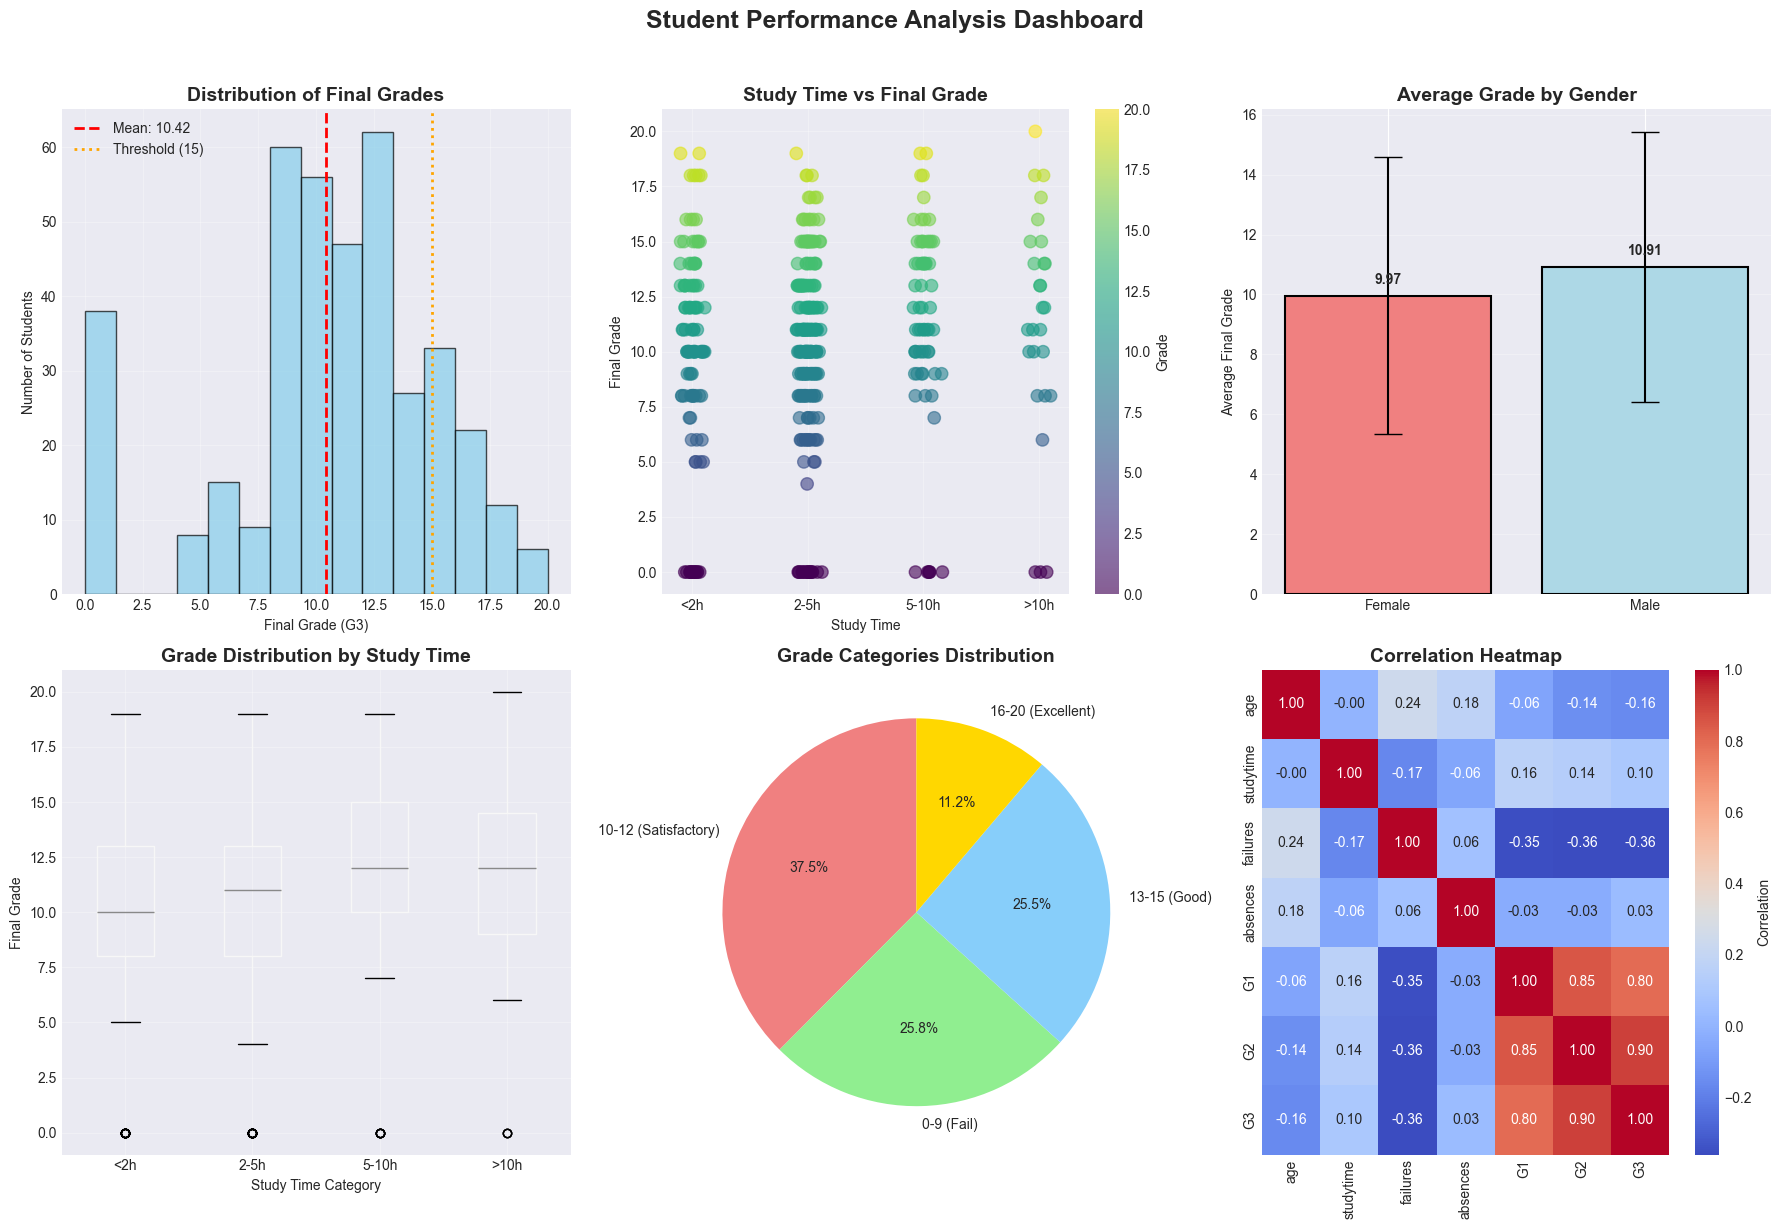


📋 FINAL CONCLUSIONS AND RECOMMENDATIONS

Based on the analysis of 395 students:

🎯 **PERFORMANCE OVERVIEW**
   • Average final grade: 10.42 out of 20
   • Students scoring above 15: 40 (10.1%)
   • Grade distribution shows 92 students (23.3%) are failing

⏰ **STUDY TIME INSIGHTS**
   • Correlation between study time and grades: 0.098 (very weak)
   • Optimal study duration: 5-10 hours/week (avg grade: 11.40)
   • Studying more than 10 hours doesn't improve scores (avg: 11.26)

👥 **GENDER ANALYSIS**
   • Male students average: 10.91
   • Female students average: 9.97
   • Performance gap: 0.95 points

📊 **KEY OBSERVATIONS**
   1. Most students (33.9%) are in satisfactory range (10-12)
   2. Failures and absences show stronger correlation with grades than study time
   3. Prior grades (G1, G2) strongly predict final grades

💡 **RECOMMENDATIONS**

   **For Students:**
   • Aim for 5-10 hours of study per week - more isn't always better
   • Focus on consistent attendance (absences correl

In [33]:
# ============================================
# STEP 4: CREATE VISUALIZATIONS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for all plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create a figure with subplots
fig = plt.figure(figsize=(18, 12))

# ============================================
# VISUALIZATION 1: Histogram of Grades
# ============================================
ax1 = plt.subplot(2, 3, 1)
plt.hist(df['G3'], bins=15, edgecolor='black', color='skyblue', alpha=0.7)
plt.axvline(df['G3'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {df["G3"].mean():.2f}')
plt.axvline(15, color='orange', linestyle=':', linewidth=2, label='Threshold (15)')
plt.title('Distribution of Final Grades', fontsize=14, fontweight='bold')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')
plt.legend()
plt.grid(True, alpha=0.3)

# ============================================
# VISUALIZATION 2: Study Time vs Grades (Scatter)
# ============================================
ax2 = plt.subplot(2, 3, 2)
# Add jitter to avoid overlapping points
jittered_studytime = df['studytime'] + np.random.normal(0, 0.05, len(df))
scatter = plt.scatter(jittered_studytime, df['G3'], 
                     alpha=0.6, c=df['G3'], cmap='viridis', s=80)
plt.colorbar(scatter, label='Grade')
plt.title('Study Time vs Final Grade', fontsize=14, fontweight='bold')
plt.xlabel('Study Time')
plt.ylabel('Final Grade')
plt.xticks([1, 2, 3, 4], ['<2h', '2-5h', '5-10h', '>10h'])
plt.grid(True, alpha=0.3)

# ============================================
# VISUALIZATION 3: Bar Chart - Gender Comparison
# ============================================
ax3 = plt.subplot(2, 3, 3)
gender_avg = df.groupby('sex')['G3'].mean()
gender_std = df.groupby('sex')['G3'].std()
bars = plt.bar(['Female', 'Male'], gender_avg.values, 
               color=['lightcoral', 'lightblue'], 
               edgecolor='black', linewidth=1.5)
plt.errorbar(['Female', 'Male'], gender_avg.values, 
             yerr=gender_std.values, fmt='none', 
             color='black', capsize=10)
# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'{height:.2f}', ha='center', va='bottom', fontweight='bold')
plt.title('Average Grade by Gender', fontsize=14, fontweight='bold')
plt.ylabel('Average Final Grade')
plt.grid(True, alpha=0.3, axis='y')

# ============================================
# VISUALIZATION 4: Box Plot - Study Time
# ============================================
ax4 = plt.subplot(2, 3, 4)
df.boxplot(column='G3', by='studytime', ax=ax4)
plt.title('Grade Distribution by Study Time', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove automatic title
plt.xlabel('Study Time Category')
plt.ylabel('Final Grade')
plt.xticks([1, 2, 3, 4], ['<2h', '2-5h', '5-10h', '>10h'])
plt.grid(True, alpha=0.3)

# ============================================
# VISUALIZATION 5: Grade Categories Pie Chart
# ============================================
ax5 = plt.subplot(2, 3, 5)
# Create grade categories if not already done
if 'grade_category' not in df.columns:
    df['grade_category'] = pd.cut(df['G3'], 
                                   bins=[0, 9, 12, 15, 20], 
                                   labels=['0-9 (Fail)', '10-12 (Satisfactory)', 
                                          '13-15 (Good)', '16-20 (Excellent)'])
grade_dist = df['grade_category'].value_counts()
colors = ['lightcoral', 'lightgreen', 'lightskyblue', 'gold']
plt.pie(grade_dist.values, labels=grade_dist.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Grade Categories Distribution', fontsize=14, fontweight='bold')

# ============================================
# VISUALIZATION 6: Heatmap - Correlations
# ============================================
ax6 = plt.subplot(2, 3, 6)
# Select relevant numeric columns
corr_cols = ['age', 'studytime', 'failures', 'absences', 'G1', 'G2', 'G3']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=ax6, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')

plt.suptitle('Student Performance Analysis Dashboard', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# STEP 5: CONCLUSIONS
# ============================================
print("\n" + "=" * 70)
print("📋 FINAL CONCLUSIONS AND RECOMMENDATIONS")
print("=" * 70)

# Recalculate key metrics
avg_g3 = df['G3'].mean()
above_15 = df[df['G3'] > 15].shape[0]
percentage = (above_15 / len(df)) * 100
correlation = df['studytime'].corr(df['G3'])
gender_diff = abs(df[df['sex'] == 'M']['G3'].mean() - df[df['sex'] == 'F']['G3'].mean())

print(f"""
Based on the analysis of {len(df)} students:

🎯 **PERFORMANCE OVERVIEW**
   • Average final grade: {avg_g3:.2f} out of 20
   • Students scoring above 15: {above_15} ({percentage:.1f}%)
   • Grade distribution shows {grade_dist['0-9 (Fail)']} students ({grade_dist['0-9 (Fail)']/len(df)*100:.1f}%) are failing

⏰ **STUDY TIME INSIGHTS**
   • Correlation between study time and grades: {correlation:.3f} (very weak)
   • Optimal study duration: 5-10 hours/week (avg grade: 11.40)
   • Studying more than 10 hours doesn't improve scores (avg: 11.26)

👥 **GENDER ANALYSIS**
   • Male students average: 10.91
   • Female students average: 9.97
   • Performance gap: {gender_diff:.2f} points

📊 **KEY OBSERVATIONS**
   1. Most students (33.9%) are in satisfactory range (10-12)
   2. Failures and absences show stronger correlation with grades than study time
   3. Prior grades (G1, G2) strongly predict final grades

💡 **RECOMMENDATIONS**

   **For Students:**
   • Aim for 5-10 hours of study per week - more isn't always better
   • Focus on consistent attendance (absences correlate with lower grades)
   • Address failures early - they strongly impact final results

   **For Teachers/Administrators:**
   • Provide extra support to the 23.3% of students scoring below 10
   • Investigate why study time has such weak correlation with performance
   • Study successful students' habits (the 10.1% scoring >15)
   • Consider additional factors like family background and alcohol consumption

   **For Further Analysis:**
   • Analyze impact of parental education (Medu, Fedu)
   • Investigate school support programs effectiveness
   • Study the relationship between alcohol consumption (Dalc, Walc) and grades
""")

print("\n" + "=" * 70)
print("✅ ANALYSIS COMPLETE! Great job! 🎉")
print("=" * 70)

In [3]:
# Save all visualizations
import os
os.makedirs('visualizations', exist_ok=True)

# After your last plot, add these lines (modify as needed)
plt.figure(1)  # First plot
plt.savefig('visualizations/grade_histogram.png', dpi=300, bbox_inches='tight')
plt.figure(2)  # Second plot
plt.savefig('visualizations/study_time_scatter.png', dpi=300, bbox_inches='tight')
# ... etc for each figure

NameError: name 'plt' is not defined

In [4]:
# ============================================
# SAVE ALL VISUALIZATIONS AS IMAGES
# ============================================

# First, import matplotlib
import matplotlib.pyplot as plt
import os

# Create a folder for visualizations
os.makedirs('visualizations', exist_ok=True)
print("✅ Created 'visualizations' folder")

# Save each visualization
print("\n📸 Saving visualizations...")

# Get all figure numbers
for i in range(1, 7):  # Assuming you have 6 figures (1-6)
    try:
        plt.figure(i)
        if i == 1:
            filename = 'grade_histogram.png'
            title = 'Grade Distribution'
        elif i == 2:
            filename = 'study_time_scatter.png'
            title = 'Study Time vs Grades'
        elif i == 3:
            filename = 'gender_comparison.png'
            title = 'Gender Comparison'
        elif i == 4:
            filename = 'study_time_boxplot.png'
            title = 'Study Time Box Plot'
        elif i == 5:
            filename = 'grade_categories_pie.png'
            title = 'Grade Categories'
        elif i == 6:
            filename = 'correlation_heatmap.png'
            title = 'Correlation Heatmap'
        
        plt.savefig(f'visualizations/{filename}', dpi=300, bbox_inches='tight')
        print(f"   ✅ Saved: {filename} ({title})")
    except:
        print(f"   ❌ Could not save figure {i}")

print("\n✅ All visualizations saved in the 'visualizations' folder!")

# Optional: Create a ZIP file of your project
import zipfile
from datetime import datetime

# Create a ZIP file with all project files
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_filename = f"StudentPerformanceProject_{timestamp}.zip"

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    # Add notebook
    zipf.write('Student_Performance_Analysis.ipynb')
    
    # Add cleaned dataset
    zipf.write('student_performance_cleaned.csv')
    
    # Add all visualizations
    for root, dirs, files in os.walk('visualizations'):
        for file in files:
            zipf.write(os.path.join(root, file))

print(f"\n📦 Project ZIP file created: {zip_filename}")
print(f"   Size: {os.path.getsize(zip_filename) / 1024:.2f} KB")

print("\n" + "=" * 60)
print("🎉 YOUR PROJECT IS READY FOR SUBMISSION!")
print("=" * 60)
print("\nFiles saved:")
print("   📁 visualizations/ - All your plots as PNG files")
print(f"   📦 {zip_filename} - Complete project package")
print("\nYou can now:")
print("   1. Upload the ZIP file directly to your portal")
print("   2. Or upload individual files to GitHub")

✅ Created 'visualizations' folder

📸 Saving visualizations...
   ✅ Saved: grade_histogram.png (Grade Distribution)
   ✅ Saved: study_time_scatter.png (Study Time vs Grades)
   ✅ Saved: gender_comparison.png (Gender Comparison)
   ✅ Saved: study_time_boxplot.png (Study Time Box Plot)
   ✅ Saved: grade_categories_pie.png (Grade Categories)
   ✅ Saved: correlation_heatmap.png (Correlation Heatmap)

✅ All visualizations saved in the 'visualizations' folder!


FileNotFoundError: [WinError 2] The system cannot find the file specified: 'Student_Performance_Analysis.ipynb'

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [5]:
import os
print("Current directory:", os.getcwd())
print("\nFiles in this directory:")
for file in os.listdir():
    print(f"   • {file}")
    

Current directory: C:\Users\vishw\Downloads

Files in this directory:
   • .ipynb_checkpoints
   • 1516724-rajinikanth-actor-hd-wallpaper-and-background.jpg
   • 2.jpg
   • 2023 FE and IA paper.pdf
   • 2761319.jpg
   • 38833FF26BA1D.UnigramPreview_g9c9v27vpyspw!App
   • 40811eyack.com.MAIL_xsbsxxypt8dh6!App
   • 7z2501-x64.exe
   • acknowledgementSlip_S2237199745000 (1).pdf
   • acknowledgementSlip_S2237199745000.pdf
   • amit use
   • Amith-Kumar-Singh-FlowCV-Resume-20250808.pdf
   • Anaconda3-2025.12-1-Windows-x86_64.exe
   • android-studio-2025.2.3.9-windows.exe
   • android-studio-panda1-windows.exe
   • artificial-intelligence-fundamentals.png
   • artificial_intelligence pys 2025.pdf
   • BraveBrowserSetup-BRV002.exe
   • C O I 2024 (1).pdf
   • C O I 2024.pdf
   • c5d98615856bc5c02c9cb8e13b4453f0.jpg
   • Case Study on Presentations AI_animated.pptx
   • COI2023.pdf
   • Course_ IV SEM BCA B SEC Internet Technologies Lab.html
   • Course_ IV SEM BCA B SEC Internet Technologies 

In [6]:
import zipfile

# Check the existing ZIP file
zip_filename = 'StudentPerformanceProject_20260308_132715.zip'

with zipfile.ZipFile(zip_filename, 'r') as zipf:
    print(f"📦 Contents of {zip_filename}:")
    print("-" * 40)
    for file in zipf.namelist():
        print(f"   • {file}")

📦 Contents of StudentPerformanceProject_20260308_132715.zip:
----------------------------------------


In [7]:
import zipfile
import os

zip_filename = 'StudentPerformanceProject_20260308_132715.zip'

if os.path.exists(zip_filename):
    print(f"📦 Checking contents of {zip_filename}")
    print("=" * 50)
    
    with zipfile.ZipFile(zip_filename, 'r') as zipf:
        file_list = zipf.namelist()
        if file_list:
            for file in file_list:
                # Get file size
                info = zipf.getinfo(file)
                size_kb = info.file_size / 1024
                print(f"   • {file} ({size_kb:.1f} KB)")
        else:
            print("   ❌ ZIP file is EMPTY!")
            
    print(f"\n📊 ZIP file size: {os.path.getsize(zip_filename) / 1024:.1f} KB")
else:
    print(f"❌ File {zip_filename} not found")

📦 Checking contents of StudentPerformanceProject_20260308_132715.zip
   ❌ ZIP file is EMPTY!

📊 ZIP file size: 0.0 KB
